In [9]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pickle as pkl
import numpy as np

In [ ]:
# load in training data (which will collapse into subspace)
with open('../data/processed/X_train.pkl', 'rb') as f:
    X_train = pkl.load(f)

In [13]:
# first standarsise data
X_train_standardised = StandardScaler().fit_transform(X_train)

# first fit seperately, to get attributes for explained variance ratio etc.
pca = PCA().fit(X_train_standardised)

# and transform to get the data
pca_data = pca.transform(X_train_standardised)

(6417938, 16)

In [22]:
per_var = np.round(pca.explained_variance_ratio_ * 100)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]

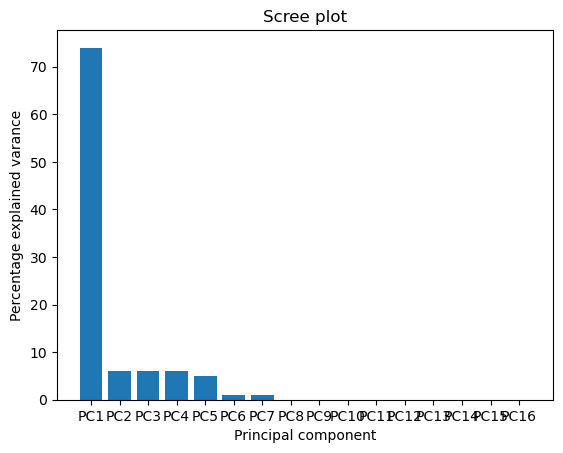

In [23]:
plt.bar(x=range(1, len(per_var)+1), height=per_var, tick_label=labels)
plt.ylabel('Percentage explained varance')
plt.xlabel('Principal component')
plt.title('Scree plot')
plt.show()

# can see that first component explains vast majoruty of variance, but 2nd, 3rd, 4th near identical

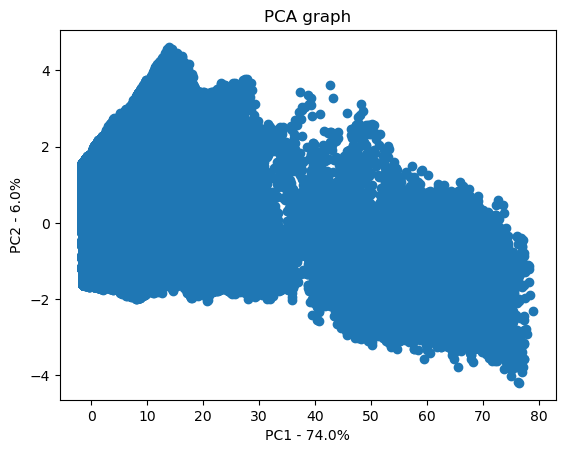

In [ ]:
# try to plot the clustered data

df_PCA = pd.DataFrame(pca_data, columns=labels)

# then create scatter plot
plt.scatter(df_PCA.PC1, df_PCA.PC2)
plt.xlabel('PC1 - {0}%'.format(per_var[0]))
plt.ylabel('PC2 - {0}%'.format(per_var[1]))
plt.title('PCA graph')
plt.show()

# can see that PC1 dominates the variance